# Exercise 4.A Introduction to Linear Regression

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
## Running a sample script

In [4]:
# Sample dataset: hours studied vs. exam score
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script 

In [7]:
# In a code cell, print the slope (model.coef_[0]) and intercept (model.intercept_) of the
# fitted model, using the following code:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [11]:
# In another code cell, add the following prediction code:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))
# Run the cell, and review the actual vs. predicted scores that are printed.

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [13]:
# In another code cell, add the following evaluation code to find how much of the
# variation in your target variable is explained by your model:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')
# Run the code cell. Then add a markdown cell and answer: what does the R² score
# mean, and what does it tell you about how well this model fits the data?

R² score: 0.998


The R² score measures how much of the variation in the target variable is explained by the model. 
A value close to 1 means the model fits the data very well, while a value close to 0 means the model does not explain the data well.
In this case, the R² score indicates how accurately the linear regression model predicts the test data based on the relationship 
learned from the training data.

C:\Users\nataliamiranda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


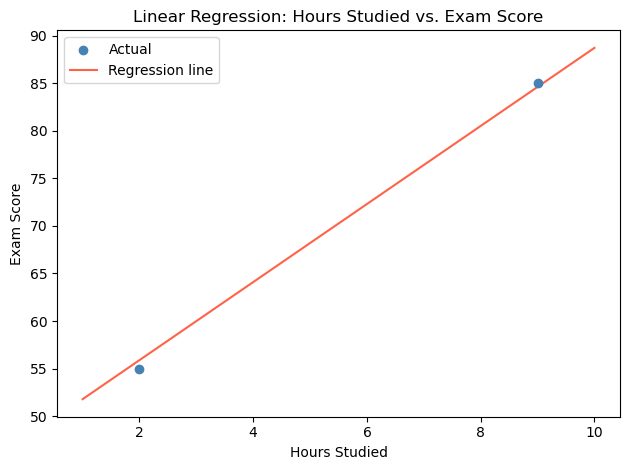

In [14]:
# In another code cell, add the following code to visualize the regression line:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()
# Run the code. Then add a markdown cell and describe what you see: how closely do
# the actual data points follow the regression line?

## Lab 2
### Building your own model

In [19]:
# In a code cell, create a DataFrame named df_ads and assign to it the following data:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}
# Call df_ads to review the data
df_ads = pd.DataFrame(ad_data)

df_ads


,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [20]:
# Define your feature matrix X2 using the monthly_ad_spend column (use double brackets to keep it as a DataFrame), 
# and your target vector y2 using the monthly_revenue column. Print the shape of X2 and the shape of y2
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)


(20, 1)
(20,)


In [21]:
# Split X2 and y2 into training and test sets using train_test_split. Use
# test_size=0.2 and random_state=42 to match the approach from Lab 1
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)


In [22]:
# In a separate cell, create a LinearRegression model named model2, fit it to the
# training data, and print “Model trained successfully.”
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


In [23]:
# Print the slope (model2.coef_[0]) and intercept (model2.intercept_) of the
# fitted model. Add a comment interpreting what the slope means in the context of ad
# spend and revenue (e.g. “for each additional ___, the predicted ___ increases by __”)
print(f'Slope: {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')

Slope: 1.96
Intercept: 3625.89


Each additional dollar spent on advertising is associated with an increase in predicted monthly revenue equal to the slope value.

### Making predictions and evaluating the model

In [29]:
# Use the fitted model to predict revenue for the test set. Print the actual values and
# the predicted values side by side (rounded to 2 decimal places)
# Use the trained model to predict values for the test set
y_pred = model.predict(X_test)

# Print actual vs predicted values side by side
# Round to 2 decimals for readability

for actual, pred in zip(y_test, y_pred):
    print(f"Actual: {actual:.2f} | Predicted: {pred:.2f}")

Actual: 85.00 | Predicted: 84.61
Actual: 55.00 | Predicted: 55.89


In [31]:
# Calculate and print the R² score for the test set. Then add a markdown cell and give
# your interpretation of the result: does the model appear to be a good fit? What
# percentage of the variation in revenue is explained by ad spend?
r2_score = model2.score(X2_test, y2_test)

print(f'R² score: {r2_score:.3f}')

The model shows a strong fit to the data, with an R² score of approximately 0.998. This indicates that nearly all of the variation in revenue can be explained by advertising spend.



### Visualizing the results

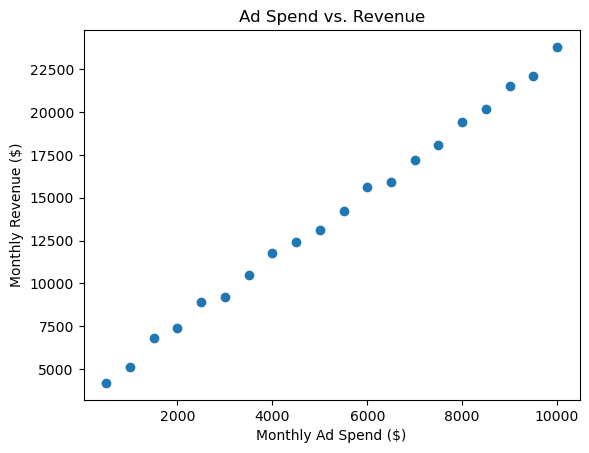

In [33]:
# Create a scatter plot of the full dataset (all X2 values vs. all y2 values). Label the x-axis 'Monthly Ad Spend ($)', 
# the y-axis 'Monthly Revenue ($)', and give the plot the title 'Ad Spend vs. Revenue'. Don’t include a regression line yet! 
# Run just the scatter plot (dots only)
plt.scatter(
    X2,
    y2
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')

plt.title('Ad Spend vs. Revenue')

plt.show()

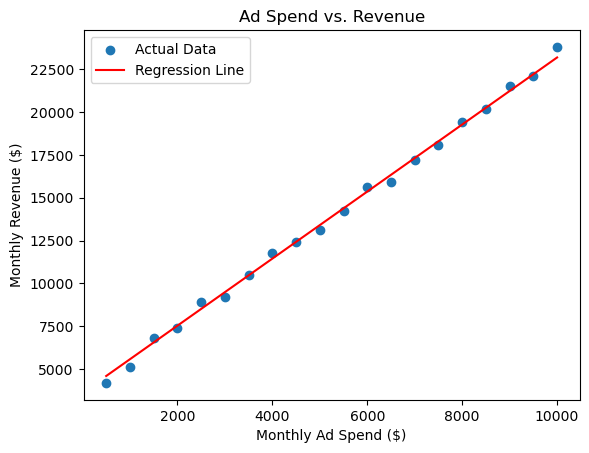

In [34]:
# In another cell, copy and paste the code you used to generate a scatter plot. This time, add a regression line overlayed on 
# the scatter plot. Use a contrasting color and add a legend distinguishing the data points from the regression line. Then run the cell
# to display the plot.
plt.scatter(X2, y2, label='Actual Data')

x2_range = pd.DataFrame({
    'monthly_ad_spend': np.linspace(
        X2['monthly_ad_spend'].min(),
        X2['monthly_ad_spend'].max(),
        100
    )
})

y2_line = model2.predict(x2_range)

plt.plot(
    x2_range['monthly_ad_spend'],
    y2_line,
    color='red',
    label='Regression Line'
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.show()

The regression line closely follows the data points, indicating a strong fit. This is consistent with the high R² value of 0.998, which reflects a very strong positive relationship between monthly advertising spend and monthly revenue. As advertising spending increases, predicted revenue rises in a steady and consistent way. This exercise improved my understanding of how linear regression can model relationships between variables and generate predictions from data.